In [ ]:
import tensorflow as tf

In [ ]:
mnist=tf.keras.datasets.mnist

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
x_train,y_train= x_train/255.0, y_train/255.0   #scaling to 0-1

In [ ]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

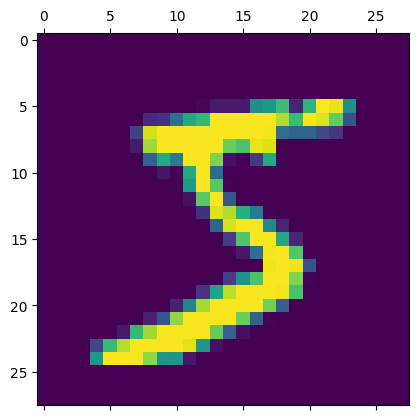

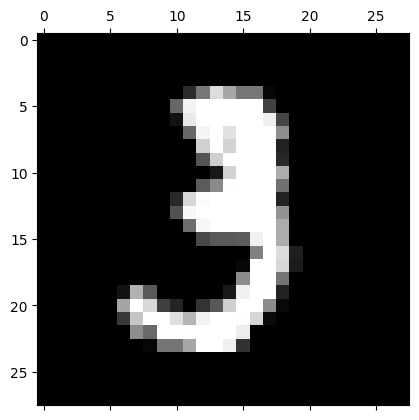

In [ ]:
import matplotlib.pyplot as plt

plt.matshow(x_train[0])

plt.matshow(x_train[10],cmap='grey')

In [ ]:
print(y_train[10])

0.011764705882352941


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
r = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,verbose=2)

Epoch 1/10
1875/1875 - 7s - 4ms/step - accuracy: 0.0987 - loss: 0.0058 - val_accuracy: 0.0980 - val_loss: 5356.6943
Epoch 2/10
1875/1875 - 6s - 3ms/step - accuracy: 0.0987 - loss: 6.9647e-06 - val_accuracy: 0.0980 - val_loss: 6228.3672
Epoch 3/10
1875/1875 - 5s - 3ms/step - accuracy: 0.0987 - loss: 2.3734e-06 - val_accuracy: 0.0980 - val_loss: 7032.4199
Epoch 4/10
1875/1875 - 5s - 3ms/step - accuracy: 0.0987 - loss: 6.7417e-07 - val_accuracy: 0.0980 - val_loss: 7717.6826
Epoch 5/10
1875/1875 - 5s - 3ms/step - accuracy: 0.0987 - loss: 2.6129e-07 - val_accuracy: 0.0980 - val_loss: 8394.8916
Epoch 6/10
1875/1875 - 5s - 3ms/step - accuracy: 0.0987 - loss: 1.1111e-07 - val_accuracy: 0.0980 - val_loss: 9159.0342
Epoch 7/10
1875/1875 - 6s - 3ms/step - accuracy: 0.0987 - loss: 2.5903e-08 - val_accuracy: 0.0980 - val_loss: 9633.7754
Epoch 8/10
1875/1875 - 6s - 3ms/step - accuracy: 0.0987 - loss: 2.1369e-08 - val_accuracy: 0.0980 - val_loss: 10385.6348
Epoch 9/10
1875/1875 - 6s - 3ms/step - accu

In [ ]:
r.history['loss']

[0.005842826794832945,
 6.9647016971430276e-06,
 2.3733589387120446e-06,
 6.741719857927819e-07,
 2.6128827812499367e-07,
 1.1111156084098184e-07,
 2.5902680889089424e-08,
 2.136928145546335e-08,
 4.744487025476474e-09,
 2.106019358905087e-09]

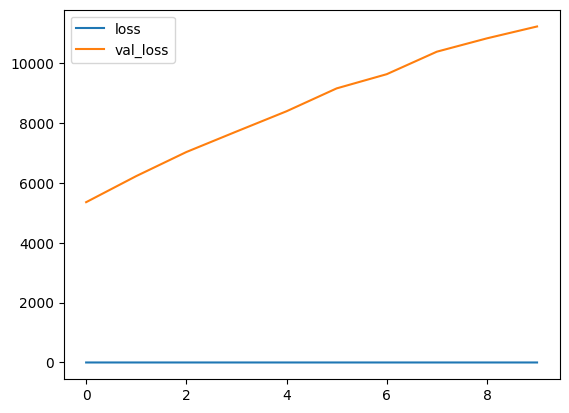

In [ ]:
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()

In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0980 - loss: 11227.8789


[11227.87890625, 0.09799999743700027]

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_test[0]

np.uint8(7)

In [ ]:
y_pred[0]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
from numpy import argmax
print(argmax(y_pred[0]))

0


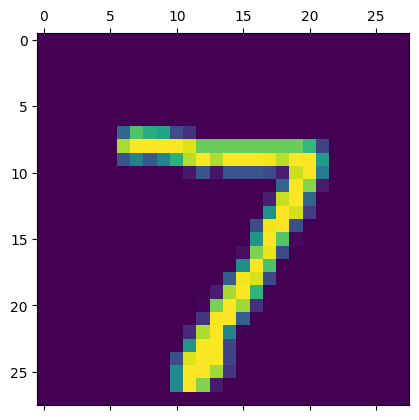

In [ ]:
plt.matshow(x_test[0])